# Actividad Módulo 2
Proyecto de análisis predictivo y modelado de datos en el deporte

- Desarrollar la capacidad para seleccionar, limpiar y preparar conjuntos de datos deportivos para su análisis predictivo.
- Aplicar técnicas de modelado predictivo avanzadas utilizando herramientas de machine learning para predecir el rendimiento deportivo o resultados de competiciones.
- Evaluar la precisión y fiabilidad de los modelos predictivos y realizar recomendaciones estratégicas basadas en los resultados.
- Fomentar el uso de visualizaciones de datos efectivas para comunicar patrones y predicciones clave.
- Sintetizar las conclusiones y recomendaciones en un informe técnico claro y estructurado.

**Autor**: Rodrigo Benito García

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, cross_validate, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, auc
)

from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Generación de datos ficticios

- **Qué debes hacer antes**: Revisa cómo crear datos ficticios coherentes, basados en ejemplos deportivos.
- **Qué necesitas**: Herramientas como Excel o Google Sheets.
- **Instrucciones**: Crea un conjunto de datos ficticios con al menos 50 registros y 5 variables que representen datos relacionados con el rendimiento deportivo.

In [2]:
df = pd.read_csv(r'Input/football_matches_dataset.csv')

In [3]:
df

,temporada,jornada,fecha,hora,equipo_local,equipo_visitante,goles_local,goles_visitante,xg_local,xg_visitante,...,duelos_terrestres_local,duelos_terrestres_visitante,intercepciones_local,intercepciones_visitante,regates_local,regates_visitante,perdidas_local,perdidas_visitante,fueras_juego_local,fueras_juego_visitante
0,2023/24,1,2023-08-11,14:00,Real Madrid,Almería,4,0,3.49,0.10,...,37,37,8.0,10.0,9.0,0.0,32,34,3,1
1,2023/24,1,2023-08-11,14:00,Barcelona,Granada,2,1,2.37,1.03,...,45,39,7.0,11.0,5.0,2.0,10,44,2,4
2,2023/24,1,2023-08-11,16:15,Atlético Madrid,Cádiz,1,1,1.03,0.93,...,33,33,5.0,14.0,NaN,2.0,16,38,1,1
3,2023/24,1,2023-08-11,16:00,Sevilla,Alavés,1,1,0.91,1.25,...,31,41,6.0,12.0,3.0,2.0,41,38,4,2
4,2023/24,1,2023-08-11,16:00,Real Sociedad,Las Palmas,0,2,0.10,1.98,...,49,42,13.0,9.0,0.0,4.0,58,34,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755,2024/25,38,2025-01-17,18:30,Las Palmas,Real Betis,1,0,1.03,NaN,...,47,34,9.0,12.0,3.0,0.0,45,68,4,4
756,2024/25,38,2025-01-17,21:00,Girona,Athletic Bilbao,1,0,1.08,0.10,...,34,39,7.0,12.0,3.0,0.0,40,39,1,0
757,2024/25,38,2025-01-17,21:00,Mallorca,Valencia,2,0,1.93,0.10,...,33,35,6.0,11.0,4.0,0.0,48,51,5,2
758,2024/25,38,2025-01-17,16:15,Rayo Vallecano,Getafe,0,0,0.10,NaN,...,36,41,8.0,5.0,0.0,0.0,42,66,5,2


## 2. Exploración y limpieza de datos

- **Qué debes hacer antes:** Aprende técnicas básicas de análisis descriptivo y limpieza de datos.
- **Qué necesitas:** Conjunto de datos ficticios generado.
- **Instrucciones:** Realiza un análisis descriptivo de los datos y limpia cualquier valor incoherente, atípico o faltante.

### 2.1. EDA

En primer lugar, para realizar el análisis descriptivo, deberemos realizar un análisis básico del dataset.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 760 entries, 0 to 759
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   temporada                    760 non-null    object 
 1   jornada                      760 non-null    int64  
 2   fecha                        760 non-null    object 
 3   hora                         760 non-null    object 
 4   equipo_local                 760 non-null    object 
 5   equipo_visitante             760 non-null    object 
 6   goles_local                  760 non-null    int64  
 7   goles_visitante              760 non-null    int64  
 8   xg_local                     700 non-null    float64
 9   xg_visitante                 700 non-null    float64
 10  tiros_local                  760 non-null    int64  
 11  tiros_visitante              760 non-null    int64  
 12  tiros_puerta_local           738 non-null    float64
 13  tiros_puerta_visitan

En segundo lugar, deberemos realizar una descripción básica de cómo se distribuyen los datos de nuestro dataset. 

Con esta función somos capaces de ver medias, desviaciones, valores mínimos y máximos, así como los percentiles.

In [5]:
df.describe()

,jornada,goles_local,goles_visitante,xg_local,xg_visitante,tiros_local,tiros_visitante,tiros_puerta_local,tiros_puerta_visitante,faltas_local,...,duelos_terrestres_local,duelos_terrestres_visitante,intercepciones_local,intercepciones_visitante,regates_local,regates_visitante,perdidas_local,perdidas_visitante,fueras_juego_local,fueras_juego_visitante
count,760.000000,760.000000,760.000000,700.000000,700.000000,760.000000,760.000000,738.000000,738.000000,760.000000,...,760.000000,760.000000,707.000000,707.000000,730.000000,730.000000,760.000000,760.000000,760.000000,760.000000
mean,19.500000,1.851316,0.942105,1.968086,1.040314,15.111842,8.603947,5.191057,2.710027,11.472368,...,39.389474,37.665789,7.595474,8.632249,5.279452,2.743836,42.706579,47.590789,1.985526,1.982895
std,10.973078,1.374624,0.946147,1.448092,0.986421,7.493826,5.633023,2.933931,2.238780,3.034588,...,7.702361,8.141624,2.148293,2.120447,4.287506,3.090118,16.078430,12.230857,1.393019,1.424784
min,1.000000,0.000000,0.000000,0.100000,0.100000,3.000000,2.000000,0.000000,0.000000,3.000000,...,15.000000,15.000000,1.000000,2.000000,0.000000,0.000000,5.000000,17.000000,0.000000,0.000000
25%,10.000000,1.000000,0.000000,0.987500,0.100000,9.000000,4.000000,3.000000,1.000000,9.000000,...,34.000000,32.000000,6.000000,7.000000,2.000000,0.000000,32.000000,39.000000,1.000000,1.000000
50%,19.500000,2.000000,1.000000,1.810000,0.970000,14.000000,7.000000,5.000000,2.000000,11.000000,...,39.000000,38.000000,8.000000,9.000000,4.000000,2.000000,42.000000,47.000000,2.000000,2.000000
75%,29.000000,3.000000,2.000000,2.920000,1.722500,20.000000,12.000000,7.000000,4.000000,14.000000,...,45.000000,43.000000,9.000000,10.000000,8.000000,4.000000,54.000000,55.000000,3.000000,3.000000
max,38.000000,7.000000,5.000000,7.580000,5.160000,30.000000,25.000000,13.000000,11.000000,22.000000,...,66.000000,68.000000,14.000000,16.000000,23.000000,19.000000,101.000000,87.000000,9.000000,7.000000


Por último, debemos ser capaces de ver de una manera rápida los valores nulos para su posterior limpieza. En nuestro caso tenemos 14 columnas con valores faltantes, en la limpieza de datos veremos cómo atacar este problema.

In [6]:
print("=" * 70)
print("ANÁLISIS DE VALORES NULOS")
print("=" * 70)

resumen = pd.DataFrame({
    'Valores_Nulos': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
})

resumen_nulos = resumen[resumen['Valores_Nulos'] > 0].sort_values('Porcentaje', ascending=False)

print(f"\nTotal de columnas: {len(resumen)}")
print(f"Total de columnas con valores nulos: {len(resumen_nulos)}")
print(f"Porcentaje total de nulos en el dataset: {round(resumen['Porcentaje'].mean(), 2)}%\n")
print(f"Total de filas en el dataset: {len(df)}\n")
print(resumen_nulos)


ANÁLISIS DE VALORES NULOS

Total de columnas: 44
Total de columnas con valores nulos: 14
Porcentaje total de nulos en el dataset: 1.57%

Total de filas en el dataset: 760

                           Valores_Nulos  Porcentaje
xg_local                              60        7.89
xg_visitante                          60        7.89
intercepciones_local                  53        6.97
intercepciones_visitante              53        6.97
duelos_aereos_local                   45        5.92
duelos_aereos_visitante               45        5.92
precision_pases_local                 38        5.00
precision_pases_visitante             38        5.00
regates_local                         30        3.95
regates_visitante                     30        3.95
tiros_puerta_local                    22        2.89
tiros_puerta_visitante                22        2.89
paradas_portero_local                 15        1.97
paradas_portero_visitante             15        1.97


### 2.2. Limpieza

Una vez descubierto que hay valores nulos, debemos de atacar este problema. Como las variables son diferentes vamos a atacarlas de distintas formas para limpiarlas.

1. **Tiros a puerta**: Utilizaremos una relación de proporción
   - Alrededor de un 35-40% de los disparos van a puerta, analizar por equipo.

2. **xG**: Utilizaremos el algoritmo KNN (K-Nearest Neighbors o K-vecinos más cercanos)
   - xG está altamente correlacionado con goles, tiros y tiros a puerta

3. **Intercepciones y Duelos**: Mediana global
   - Existe menos variabilidad entre equipos

4. **Precisión de pases, Regates, Paradas del Portero**: Mediana por equipo
   - Cada equipo tiene su propio estilo y nivel
   - Los equipos técnicos regatean más que equipos físicos
   - Calidad del portero varía por equipo

#### 2.2.1. Tiros a puerta

In [7]:
proporcion_global_local = (df['tiros_puerta_local'] / df['tiros_local']).median()
proporcion_global_visitante = (df['tiros_puerta_visitante'] / df['tiros_visitante']).median()

for equipo in df['equipo_local'].unique():
    # LOCAL
    mask_equipo = df['equipo_local'] == equipo
    df_temp = df[mask_equipo & ~df['tiros_puerta_local'].isnull()]
    
    # Calcular proporción del equipo (o usar global si no hay datos)
    if len(df_temp) > 0:
        prop_equipo = (df_temp['tiros_puerta_local'] / df_temp['tiros_local']).median()
    else:
        prop_equipo = proporcion_global_local
    
    # Aplicar imputación
    mask_null = mask_equipo & df['tiros_puerta_local'].isnull()
    df.loc[mask_null, 'tiros_puerta_local'] = (
        df.loc[mask_null, 'tiros_local'] * prop_equipo
    ).round(0)
    
    # VISITANTE
    mask_equipo_vis = df['equipo_visitante'] == equipo
    df_temp_vis = df[mask_equipo_vis & ~df['tiros_puerta_visitante'].isnull()]
    
    if len(df_temp_vis) > 0:
        prop_equipo_vis = (df_temp_vis['tiros_puerta_visitante'] / df_temp_vis['tiros_visitante']).median()
    else:
        prop_equipo_vis = proporcion_global_visitante
    
    mask_null_vis = mask_equipo_vis & df['tiros_puerta_visitante'].isnull()
    df.loc[mask_null_vis, 'tiros_puerta_visitante'] = (
        df.loc[mask_null_vis, 'tiros_visitante'] * prop_equipo_vis
    ).round(0)

print("✅ Tiros a puerta imputados usando proporción específica por equipo")
print(f"   Nulos restantes: {df['tiros_puerta_local'].isnull().sum()} local")
print(f"   Nulos restantes: {df['tiros_puerta_visitante'].isnull().sum()} visitante")

✅ Tiros a puerta imputados usando proporción específica por equipo
   Nulos restantes: 0 local
   Nulos restantes: 0 visitante


#### 2.2.2. xG

In [8]:
print("\nImputando xG usando KNN Imputer...")
features_for_xg = [
    'goles_local', 'goles_visitante', 
    'tiros_local', 'tiros_visitante',
    'tiros_puerta_local', 'tiros_puerta_visitante',
    'xg_local', 'xg_visitante'
]

# Filtrar solo columnas que existen y no tienen todos nulos
features_available = [col for col in features_for_xg if col in df.columns]

imputer_knn = KNNImputer(n_neighbors=5, weights='distance')
df[features_available] = imputer_knn.fit_transform(df[features_available])

print(f"   Nulos restantes: {df['xg_local'].isnull().sum()} local")
print(f"   Nulos restantes: {df['xg_visitante'].isnull().sum()} visitante")


Imputando xG usando KNN Imputer...
   Nulos restantes: 0 local
   Nulos restantes: 0 visitante


#### 2.2.3. Intercepciones y duelos

In [9]:
print("Imputando duelos e intercepciones por mediana...")
columnas_mediana = [
    'duelos_aereos_local', 'duelos_aereos_visitante',
    'intercepciones_local', 'intercepciones_visitante'
]
for col in columnas_mediana:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

print(f"   Nulos restantes: {df['duelos_aereos_local'].isnull().sum()} duelos local")
print(f"   Nulos restantes: {df['duelos_aereos_visitante'].isnull().sum()} duelos visitante")

print(f"   Nulos restantes: {df['intercepciones_local'].isnull().sum()} intercepciones local")
print(f"   Nulos restantes: {df['intercepciones_visitante'].isnull().sum()} intercepciones visitante")

Imputando duelos e intercepciones por mediana...
   Nulos restantes: 0 duelos local
   Nulos restantes: 0 duelos visitante
   Nulos restantes: 0 intercepciones local
   Nulos restantes: 0 intercepciones visitante


#### 2.2.4. Precisión de pases, Regates, Paradas del Portero

In [10]:
print("Imputando precisión de pases, regates y paradas del portero por mediana de equipo...")
for col in ['precision_pases_local', 'precision_pases_visitante', 'regates_local', 'regates_visitante', 'paradas_portero_local', 'paradas_portero_visitante']:
    equipo_col = 'equipo_local' if 'local' in col else 'equipo_visitante'
    df[col] = df.groupby(equipo_col)[col].transform(
        lambda x: x.fillna(x.median())
    )
    # Si aún quedan nulos (equipos sin datos), usar mediana global
    df[col] = df[col].fillna(df[col].median())

print(f"   Nulos restantes: {df['precision_pases_local'].isnull().sum()} pases local")
print(f"   Nulos restantes: {df['precision_pases_visitante'].isnull().sum()} pases visitante")

print(f"   Nulos restantes: {df['regates_local'].isnull().sum()} regates local")
print(f"   Nulos restantes: {df['regates_visitante'].isnull().sum()} regates visitante")

print(f"   Nulos restantes: {df['paradas_portero_local'].isnull().sum()} paradas portero local")
print(f"   Nulos restantes: {df['paradas_portero_visitante'].isnull().sum()} paradas portero visitante")

Imputando precisión de pases, regates y paradas del portero por mediana de equipo...
   Nulos restantes: 0 pases local
   Nulos restantes: 0 pases visitante
   Nulos restantes: 0 regates local
   Nulos restantes: 0 regates visitante
   Nulos restantes: 0 paradas portero local
   Nulos restantes: 0 paradas portero visitante


### 2.3. EDA después de la limpieza

In [11]:
print("=" * 70)
print("ANÁLISIS DE VALORES NULOS DESPUÉS DE LA LIMPIEZA")
print("=" * 70)

resumen = pd.DataFrame({
    'Valores_Nulos': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
})

resumen_nulos = resumen[resumen['Valores_Nulos'] > 0].sort_values('Porcentaje', ascending=False)

print(f"\nTotal de columnas: {len(resumen)}")
print(f"Total de columnas con valores nulos: {len(resumen_nulos)}")
print(f"Porcentaje total de nulos en el dataset: {round(resumen['Porcentaje'].mean(), 2)}%\n")
print(f"Total de filas en el dataset: {len(df)}\n")

ANÁLISIS DE VALORES NULOS DESPUÉS DE LA LIMPIEZA

Total de columnas: 44
Total de columnas con valores nulos: 0
Porcentaje total de nulos en el dataset: 0.0%

Total de filas en el dataset: 760



### 2.4. Detección de outliers

In [17]:
def detectar_outliers_zscore(df, columna, umbral=3):
    """Detecta outliers usando Z-score"""
    z_scores = np.abs(stats.zscore(df[columna].dropna()))
    outliers_mask = z_scores > umbral
    n_outliers = outliers_mask.sum()
    
    return {
        'columna': columna,
        'n_outliers': n_outliers,
        'porcentaje': (n_outliers / len(df)) * 100
    }

resultados_outliers = []
for col in df.columns:
    if col not in ['temporada', 'jornada', 'fecha', 'hora', 'equipo_local', 'equipo_visitante']:
        resultado = detectar_outliers_zscore(df, col)
        if resultado['n_outliers'] > 0:
            resultados_outliers.append({
                'Columna': resultado['columna'],
                'N_Outliers': resultado['n_outliers'],
                'Porcentaje %': round(resultado['porcentaje'], 2)
            })

# Crear DataFrame y ordenar
df_outliers = pd.DataFrame(resultados_outliers)
df_outliers = df_outliers.sort_values('Porcentaje %', ascending=False)

print("="*70)
print("OUTLIERS DETECTADOS - MÉTODO Z-SCORE -\nORDENADOS POR PORCENTAJE")
print("="*70)
print(df_outliers.to_string(index=False))

# Estadísticas adicionales
print(f"\n📊 RESUMEN:")
print(f"  - Total de columnas con outliers: {len(df_outliers)}")
print(f"  - Columna con más outliers: {df_outliers.iloc[0]['Columna']} ({df_outliers.iloc[0]['Porcentaje %']:.2f}%)")

print(f"  - Promedio de outliers por columna: {df_outliers['Porcentaje %'].mean():.2f}%")

OUTLIERS DETECTADOS - MÉTODO Z-SCORE -
ORDENADOS POR PORCENTAJE
                    Columna  N_Outliers  Porcentaje %
            rojas_visitante          41          5.39
                rojas_local          34          4.47
                goles_local          10          1.32
          corners_visitante           9          1.18
          regates_visitante           9          1.18
            goles_visitante           9          1.18
               xg_visitante           7          0.92
     tiros_puerta_visitante           7          0.92
              regates_local           6          0.79
      paradas_portero_local           6          0.79
                   xg_local           5          0.66
     fueras_juego_visitante           5          0.66
         despejes_visitante           4          0.53
   intercepciones_visitante           4          0.53
             perdidas_local           4          0.53
         fueras_juego_local           4          0.53
       intercepcio

VISUALIZACIÓN DE TOP 10 OUTLIERS


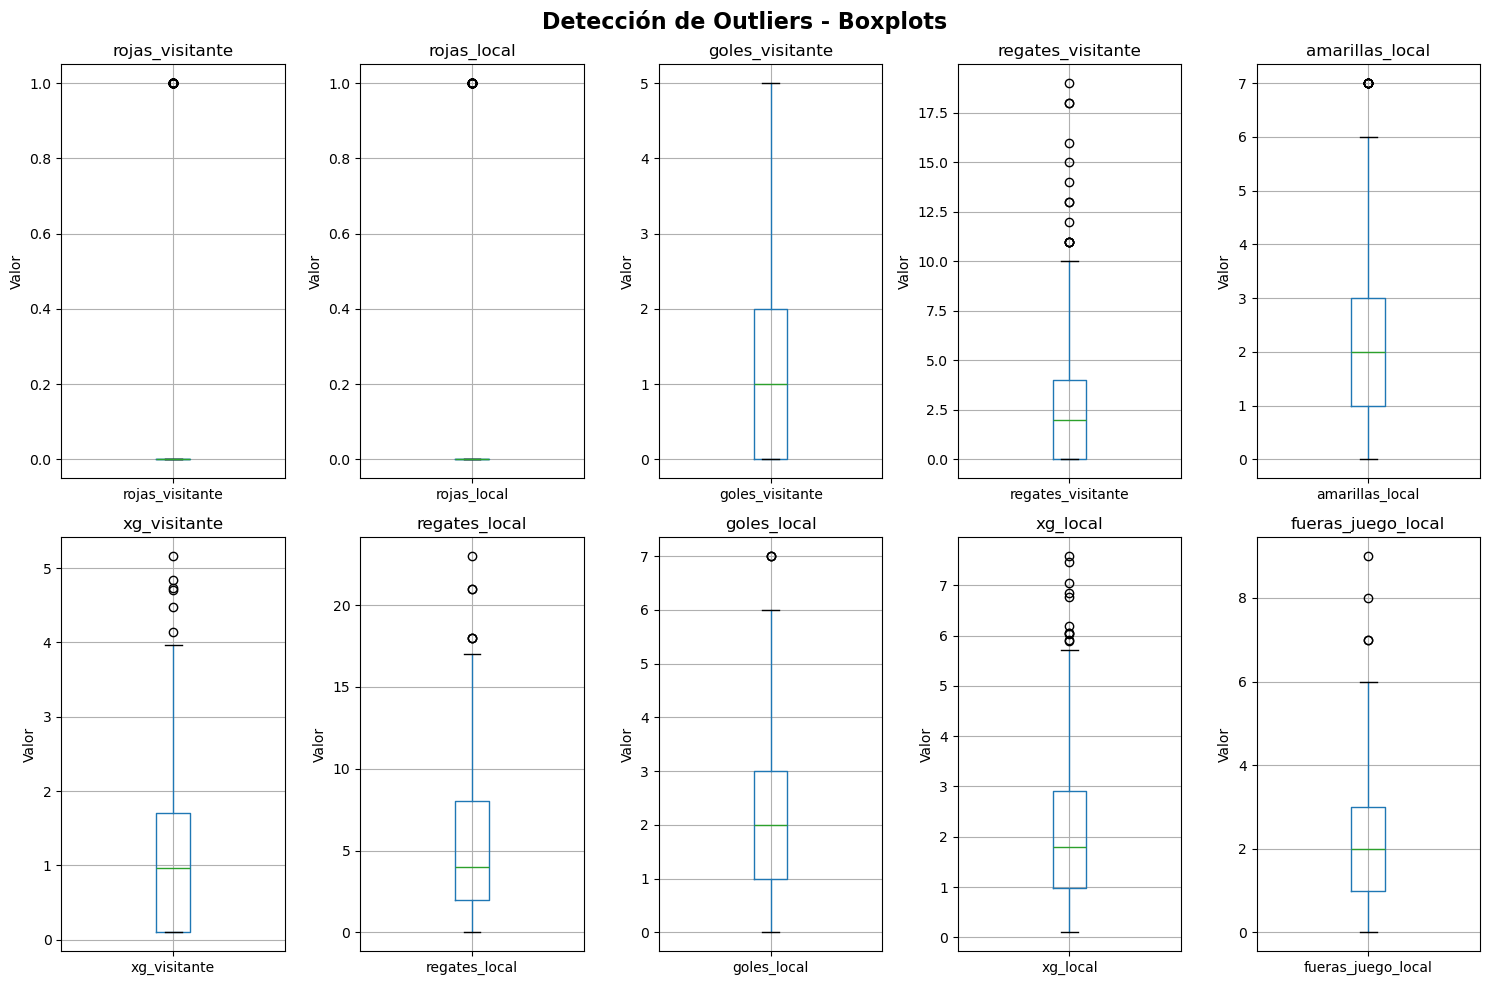

In [13]:
print("="*70)
print("VISUALIZACIÓN DE TOP 10 OUTLIERS")
print("="*70)

# Boxplots para detectar outliers visualmente
fig, axes = plt.subplots(2, 5, figsize=(15, 10))
fig.suptitle('Detección de Outliers - Boxplots', fontsize=16, fontweight='bold')

columnas_clave = ['rojas_visitante', 'rojas_local', 'goles_visitante', 'regates_visitante', 
                  'amarillas_local', 'xg_visitante', 'regates_local', 'goles_local',
                  'xg_local', 'fueras_juego_local']

for idx, col in enumerate(columnas_clave):
    ax = axes[idx // 5, idx % 5]
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
    ax.set_ylabel('Valor')

plt.tight_layout()

Tras la visualización del top 10 de outliers se sacan las siguientes conclusiones:

1. **Tarjetas Rojas (5.39% y 4.47%)**:
   - Mayor porcentaje de outliers detectados
   - Explicación: Variable binaria con eventos poco frecuentes
   - En fútbol, ~10% de partidos tienen expulsiones
   - Son eventos legítimos, no errores de datos

2. **Goles (1.31% y 1.18%)**:
   - Representan goleadas históricas (5+ goles)
   - Ejemplos: Barcelona vs equipos débiles
   - Reflejan diferencias competitivas reales

3. **Regates (0.79% y 1.18%)**:
   - Jugadores de élite técnica
   - Partidos con dominancia ofensiva extrema

En resumen, se mantienen todos los outliers identificados porque:
   - Son eventos deportivos válidos
   - Reflejan la variabilidad natural del rendimiento de los equipos
   - Los modelos deben aprender de casos extremos
   - No se detectaron errores de medición o entrada de datos

Mantener estos outliers garantiza que los modelos predictivos capturen la realidad completa del fútbol profesional, incluyendo eventos excepcionales.

### 2.5. Correlación de variables
En este apartado comprobaremos cual es la relación que existe entre los goles, xG, posesión, tiros, etc...


Matriz de correlación (sin normalizar):


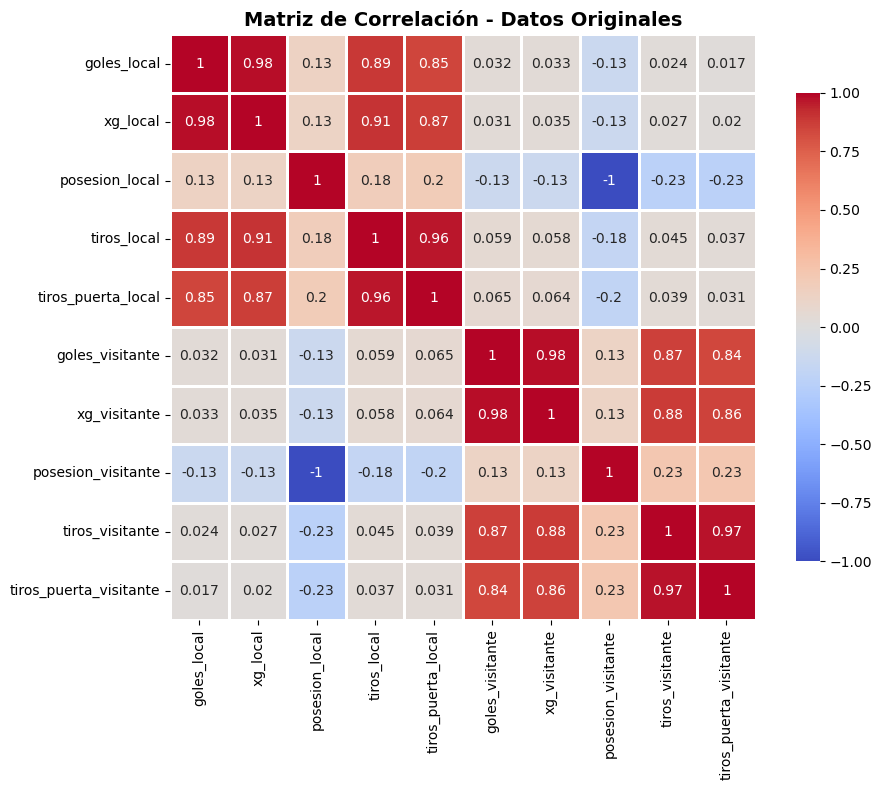

In [14]:
columnas_clave = ['goles_local', 'xg_local', 'posesion_local', 'tiros_local', 'tiros_puerta_local',
                  'goles_visitante', 'xg_visitante', 'posesion_visitante',  'tiros_visitante', 'tiros_puerta_visitante']

print("\nMatriz de correlación (sin normalizar):")
correlation_matrix = df[columnas_clave].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Datos Originales', fontsize=14, fontweight='bold')
plt.tight_layout()


Podemos observar en la matriz, como cabía esperar:
- Las variables de goles están muy correlacionadas con los xG, los tiros y tiros a puerta, no tanto con la posesión.
- Comparar variables locales contra variables visitante, vemos una clara correlación negativa.
- La posesión tiene la mayor correlación negativa, ya que un evento es complementario al otro.

### 2.6. Guardar dataset limpio

In [15]:
df.to_csv(r'/Users/rodrigobenitogarcia/Desktop/RODRIGO BENITO GARCIA/Master Big Data e IA aplicado al Deporte/Módulo 2 - Análisis, predicción y modelado de datos/Practica 2 - Proyecto de análisis predictivo y modelado de datos en el deporte/football_matches_dataset_clean.csv', index=False)
print("✅ Dataset limpio guardado: 'football_matches_dataset_clean.csv'")

✅ Dataset limpio guardado: 'football_matches_dataset_clean.csv'


## 3. Modelado predictivo

- **Qué debes hacer antes**: Investiga los tipos de modelos predictivos utilizados en el deporte.
- **Qué necesitas**: Conjunto de datos limpio y herramientas como Excel o Python.
- **Instrucciones**: Elige y aplica un modelo predictivo adecuado para realizar predicciones, y justifica tu elección.

In [18]:
df_clean = pd.read_csv(r'Input/football_matches_dataset_clean.csv')

### 3.1. Calcular variable objetivo real

In [ ]:
print("="*80)
print("REGRESIÓN LINEAL - PREDICCIÓN PUNTOS POR EQUIPO Y TEMPORADA")
print("="*80)
print("\nCalculando puntos reales por equipo y temporada...")
print("-"*80)

# Función para calcular puntos
def calcular_puntos(row, como='local'):
    """Calcula los puntos obtenidos en un partido"""

    if como == 'local':
        goles_favor = row['goles_local']
        goles_contra = row['goles_visitante']
    else:  # visitante
        goles_favor = row['goles_visitante']
        goles_contra = row['goles_local']
    
    if goles_favor > goles_contra:
        return 3  # Victoria
    elif goles_favor == goles_contra:
        return 1  # Empate
    else:
        return 0  # Derrota

# Calcular puntos por partido
df_clean['puntos_local'] = df_clean.apply(lambda row: calcular_puntos(row, 'local'), axis=1)
df_clean['puntos_visitante'] = df_clean.apply(lambda row: calcular_puntos(row, 'visitante'), axis=1)

# Crear dataset por equipo (considerando partidos como local Y visitante)
equipos_stats = []

for temporada in df_clean['temporada'].unique():
    df_clean_temp = df_clean[df_clean['temporada'] == temporada]
    
    for equipo in df_clean_temp['equipo_local'].unique():
        # Partidos como local
        partidos_local = df_clean_temp[df_clean_temp['equipo_local'] == equipo]
        # Partidos como visitante
        partidos_visitante = df_clean_temp[df_clean_temp['equipo_visitante'] == equipo]
        
        # Calcular estadísticas agregadas
        stats = {
            'temporada': temporada,
            'equipo': equipo,
            'partidos_jugados': len(partidos_local) + len(partidos_visitante),
            
            # PUNTOS (variable objetivo)
            'puntos_totales': partidos_local['puntos_local'].sum() + partidos_visitante['puntos_visitante'].sum(),
            
            # Features - Promedios por partido
            'avg_posesion': (partidos_local['posesion_local'].mean() + partidos_visitante['posesion_visitante'].mean()) / 2,
            'avg_tiros': (partidos_local['tiros_local'].mean() + partidos_visitante['tiros_visitante'].mean()) / 2,
            'avg_tiros_puerta': (partidos_local['tiros_puerta_local'].mean() + partidos_visitante['tiros_puerta_visitante'].mean()) / 2,
            'avg_corners': (partidos_local['corners_local'].mean() + partidos_visitante['corners_visitante'].mean()) / 2,
            'avg_paradas_portero': (partidos_local['paradas_portero_local'].mean() + partidos_visitante['paradas_portero_visitante'].mean()) / 2,
            'avg_precision_pases': (partidos_local['precision_pases_local'].mean() + partidos_visitante['precision_pases_visitante'].mean()) / 2,
            'avg_faltas': (partidos_local['faltas_local'].mean() + partidos_visitante['faltas_visitante'].mean()) / 2,
            'avg_amarillas': (partidos_local['amarillas_local'].mean() + partidos_visitante['amarillas_visitante'].mean()) / 2,
            'avg_duelos_aereos': (partidos_local['duelos_aereos_local'].mean() + partidos_visitante['duelos_aereos_visitante'].mean()) / 2,
            'avg_duelos_terrestres': (partidos_local['duelos_terrestres_local'].mean() + partidos_visitante['duelos_terrestres_visitante'].mean()) / 2,
            'avg_regates': (partidos_local['regates_local'].mean() + partidos_visitante['regates_visitante'].mean()) / 2,
            'avg_intercepciones': (partidos_local['intercepciones_local'].mean() + partidos_visitante['intercepciones_visitante'].mean()) / 2,
        }
        
        equipos_stats.append(stats)

# Crear DataFrame de equipos
df_equipos = pd.DataFrame(equipos_stats)

print(f"\nDataset de equipos creado: {len(df_equipos)} registros")
print(f"   (20 equipos x 2 temporadas = 40 registros)")

# Mostrar primeros equipos
print("\nPrimeros 5 equipos:")
print(df_equipos.head())

# Estadísticas de puntos
print("\nDistribución de puntos por temporada:")
print(df_equipos.groupby('temporada')['puntos_totales'].describe())


Calculando puntos reales por equipo y temporada...
--------------------------------------------------------------------------------

Dataset de equipos creado: 40 registros
   (20 equipos x 2 temporadas = 40 registros)

Primeros 5 equipos:
  temporada           equipo  partidos_jugados  puntos_totales  avg_posesion  \
0   2023/24      Real Madrid                38              60     58.660526   
1   2023/24        Barcelona                38              64     58.660526   
2   2023/24  Atlético Madrid                38              57     58.660526   
3   2023/24          Sevilla                38              62     54.152632   
4   2023/24    Real Sociedad                38              57     54.152632   

   avg_tiros  avg_tiros_puerta  avg_corners  avg_paradas_portero  \
0  15.157895          5.210526     7.105263             2.815789   
1  15.631579          5.263158     7.289474             2.473684   
2  16.000000          5.526316     7.973684             3.105263   
3  13.

In [50]:
print("="*80)
print("REGRESIÓN LOGÍSTICA - PREDICCIÓN OVER 2.5 GOLES")
print("="*80)

print("\nCreando variable objetivo binaria...")
print("-"*80)

# Calcular total de goles por partido
df_clean['total_goles'] = df_clean['goles_local'] + df_clean['goles_visitante']

# Crear variable binaria: 1 si > 2.5 goles, 0 si <= 2.5
df_clean['over_2_5'] = (df_clean['total_goles'] > 2.5).astype(int)

# Distribución de la variable objetivo
print(f"\n🎯 Distribución de la variable objetivo:")
print(df_clean['over_2_5'].value_counts())
print(f"\nPorcentajes:")
print(df_clean['over_2_5'].value_counts(normalize=True) * 100)

# Balance de clases
clase_mayoritaria = df_clean['over_2_5'].value_counts().max()
clase_minoritaria = df_clean['over_2_5'].value_counts().min()
ratio_balance = clase_minoritaria / clase_mayoritaria

print(f"\nBalance de clases: {ratio_balance:.2%}")
if ratio_balance > 0.4:
    print("Dataset balanceado")
else:
    print("Dataset desbalanceado")


REGRESIÓN LOGÍSTICA - PREDICCIÓN OVER 2.5 GOLES

Creando variable objetivo binaria...
--------------------------------------------------------------------------------

🎯 Distribución de la variable objetivo:
over_2_5
1    388
0    372
Name: count, dtype: int64

Porcentajes:
over_2_5
1    51.052632
0    48.947368
Name: proportion, dtype: float64

Balance de clases: 95.88%
Dataset balanceado


### 3.2. Preparar features y variable objetivo

In [28]:
print("\n\nPreparando features y target...")
print("-"*80)

# Features seleccionadas (SIN goles ni xG)
features = [
    'avg_tiros_puerta',
    'avg_precision_pases',
    'avg_posesion',
    'avg_corners',
    'avg_duelos_terrestres',
    'avg_paradas_portero'
]

# Variable objetivo
target = 'puntos_totales'

# Verificar valores nulos
print(f"\nVerificando valores nulos en features:")
print(df_equipos[features].isnull().sum())

# Eliminar filas con valores nulos si hay
df_equipos_clean = df_equipos.dropna(subset=features + [target])
print(f"\nRegistros después de eliminar nulos: {len(df_equipos_clean)}")

# Preparar X e y
X = df_equipos_clean[features]
y = df_equipos_clean[target]

print(f"\nDimensiones del dataset:")
print(f"   X (features): {X.shape}")
print(f"   y (target): {y.shape}")

print(f"\nFeatures utilizadas:")
for i, feature in enumerate(features, 1):
    print(f"   {i:2d}. {feature}")

print(f"\nVariable objetivo: {target}")
print(f"   Rango: {y.min():.0f} - {y.max():.0f} puntos")
print(f"   Media: {y.mean():.2f} puntos")
print(f"   Mediana: {y.median():.0f} puntos")



Preparando features y target...
--------------------------------------------------------------------------------

Verificando valores nulos en features:
avg_tiros_puerta         0
avg_precision_pases      0
avg_posesion             0
avg_corners              0
avg_duelos_terrestres    0
avg_paradas_portero      0
dtype: int64

Registros después de eliminar nulos: 40

Dimensiones del dataset:
   X (features): (40, 6)
   y (target): (40,)

Features utilizadas:
    1. avg_tiros_puerta
    2. avg_precision_pases
    3. avg_posesion
    4. avg_corners
    5. avg_duelos_terrestres
    6. avg_paradas_portero

Variable objetivo: puntos_totales
   Rango: 36 - 69 puntos
   Media: 52.58 puntos
   Mediana: 54 puntos


In [29]:
print("\n\nPreparando features y target...")
print("-"*80)

# Features seleccionadas (SIN goles ni xG)
features_2_5 = [
    # Ofensivas
    'tiros_local',
    'tiros_visitante',
    'tiros_puerta_local',
    'tiros_puerta_visitante',
    'corners_local',
    'corners_visitante',
    
    # Posesión y control
    'posesion_local',
    'posesion_visitante',
    'precision_pases_local',
    'precision_pases_visitante',
    
    # Intensidad del partido
    'faltas_local',
    'faltas_visitante',
    'amarillas_local',
    'amarillas_visitante',
    
    # Acciones técnicas
    'regates_local',
    'regates_visitante',
    'duelos_terrestres_local',
    'duelos_terrestres_visitante'
]

X_2_5 = df_clean[features_2_5]
y_2_5 = df_clean['over_2_5']

print(f"\nDimensiones del dataset:")
print(f"   Total partidos: {len(X_2_5)}")
print(f"   Features: {len(features_2_5)}")
print(f"   Over 2.5: {y_2_5.sum()} partidos ({y_2_5.sum()/len(y_2_5)*100:.1f}%)")
print(f"   Under 2.5: {(y_2_5==0).sum()} partidos ({(y_2_5==0).sum()/len(y_2_5)*100:.1f}%)")

print(f"\nFeatures utilizadas ({len(features_2_5)}):")
for i, feature in enumerate(features_2_5, 1):
    print(f"   {i:2d}. {feature}")




Preparando features y target...
--------------------------------------------------------------------------------

Dimensiones del dataset:
   Total partidos: 760
   Features: 18
   Over 2.5: 388 partidos (51.1%)
   Under 2.5: 372 partidos (48.9%)

Features utilizadas (18):
    1. tiros_local
    2. tiros_visitante
    3. tiros_puerta_local
    4. tiros_puerta_visitante
    5. corners_local
    6. corners_visitante
    7. posesion_local
    8. posesion_visitante
    9. precision_pases_local
   10. precision_pases_visitante
   11. faltas_local
   12. faltas_visitante
   13. amarillas_local
   14. amarillas_visitante
   15. regates_local
   16. regates_visitante
   17. duelos_terrestres_local
   18. duelos_terrestres_visitante


### 3.3. Train/Test

In [30]:
print("\n\nTrain/Test Split...")
print("-"*80)

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Distribución del split:")
print(f"\tTrain: {len(X_train)} registros ({len(X_train)/len(X)*100:.1f}%)")
print(f"\tTest:  {len(X_test)} registros ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nEstadísticas de puntos:")
print(f"\tTrain - Media: {y_train.mean():.2f}, Min: {y_train.min():.0f}, Max: {y_train.max():.0f}")
print(f"\tTest  - Media: {y_test.mean():.2f}, Min: {y_test.min():.0f}, Max: {y_test.max():.0f}")




Train/Test Split...
--------------------------------------------------------------------------------
Distribución del split:
	Train: 32 registros (80.0%)
	Test:  8 registros (20.0%)

Estadísticas de puntos:
	Train - Media: 52.97, Min: 36, Max: 69
	Test  - Media: 51.00, Min: 36, Max: 57


In [ ]:
print("\n\nTrain/Test Split...")
print("-"*80)

# Split 80% train, 20% test
X_2_5_train, X_2_5_test, y_2_5_train, y_2_5_test = train_test_split(
    X_2_5, y_2_5,
    test_size=0.2,
    random_state=42,
    stratify=y_2_5 
)

print(f"Distribución del split:")
print(f"   Train: {len(X_2_5_train)} partidos ({len(X_2_5_train)/len(X_2_5)*100:.1f}%)")
print(f"   Test:  {len(X_2_5_test)} partidos ({len(X_2_5_test)/len(X_2_5)*100:.1f}%)")

print(f"\nDistribución de clases:")
print(f"   Train - Over 2.5: {y_2_5_train.sum()} ({y_2_5_train.sum()/len(y_2_5_train)*100:.1f}%)")
print(f"   Test  - Over 2.5: {y_2_5_test.sum()} ({y_2_5_test.sum()/len(y_2_5_test)*100:.1f}%)")

print("\n\nNormalizando features para regresion logística...")
print("-"*80)
scaler = StandardScaler()
X_2_5_train_scaled = scaler.fit_transform(X_2_5_train)
X_2_5_test_scaled = scaler.transform(X_2_5_test)

print("Features normalizadas con StandardScaler")
print(f"   Media después de escalar: {X_2_5_train_scaled.mean():.6f}")
print(f"   Std después de escalar: {X_2_5_train_scaled.std():.6f}")




Train/Test Split...
--------------------------------------------------------------------------------
Distribución del split:
   Train: 608 partidos (80.0%)
   Test:  152 partidos (20.0%)

Distribución de clases:
   Train - Over 2.5: 310 (51.0%)
   Test  - Over 2.5: 78 (51.3%)


Normalizando features para regresion logística...
--------------------------------------------------------------------------------
Features normalizadas con StandardScaler
   Media después de escalar: 0.000000
   Std después de escalar: 1.000000


### 3.4. Entrenar modelos

#### 3.4.1. Regresión lineal

In [31]:
print("\n\nEntrenando Regresión Lineal...")
print("-"*80)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Modelo entrenado exitosamente!")

# Coeficientes
print(f"\n📊 Coeficientes del modelo:")
coeficientes = pd.DataFrame({
    'Feature': features,
    'Coeficiente': modelo.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print(coeficientes.to_string(index=False))
print(f"\nIntercept: {modelo.intercept_:.2f}")



Entrenando Regresión Lineal...
--------------------------------------------------------------------------------
Modelo entrenado exitosamente!

📊 Coeficientes del modelo:
              Feature  Coeficiente
     avg_tiros_puerta     9.367327
  avg_paradas_portero    -5.786060
          avg_corners     2.390773
avg_duelos_terrestres     0.541881
  avg_precision_pases    -0.538360
         avg_posesion     0.325320

Intercept: 10.43


#### 3.4.2. Validación cruzada con regresión lineal

In [32]:
print("\n\n🔄 VALIDACIÓN CRUZADA - REGRESIÓN LINEAL")
print("-"*80)

# Configuración de K-Fold=5
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

print(f"Configuración: {k_folds}-Fold Cross-Validation")
print(f"  • Cada fold tendrá ~{len(X)//k_folds} registros de test\n")

# Modelo
modelo_lr = LinearRegression()

# Cross-validation con múltiples métricas
cv_results = cross_validate(
    modelo_lr,
    X,
    y,
    cv=kf,
    scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error'],
    return_train_score=True,
    return_estimator=True  # Guardar modelos de cada fold
)

print("Modelo entrenado exitosamente!")

# Resultados
r2_train_cv = cv_results['train_r2']
r2_test_cv = cv_results['test_r2']
mae_cv = -cv_results['test_neg_mean_absolute_error']
rmse_cv = -cv_results['test_neg_root_mean_squared_error']

print(f"📊 Resultados por Fold:")
print(f"\n{'Fold':<6} {'R² Train':<12} {'R² Test':<12} {'MAE':<10} {'RMSE':<10}")
print("-"*54)
for i in range(k_folds):
    print(f"{i+1:<6} {r2_train_cv[i]:<12.4f} {r2_test_cv[i]:<12.4f} {mae_cv[i]:<10.2f} {rmse_cv[i]:<10.2f}")



🔄 VALIDACIÓN CRUZADA - REGRESIÓN LINEAL
--------------------------------------------------------------------------------
Configuración: 5-Fold Cross-Validation
  • Cada fold tendrá ~8 registros de test

Modelo entrenado exitosamente!
📊 Resultados por Fold:

Fold   R² Train     R² Test      MAE        RMSE      
------------------------------------------------------
1      0.7482       0.4353       4.66       5.38      
2      0.7052       0.6550       2.90       3.87      
3      0.7872       -0.1864      6.20       7.24      
4      0.7361       0.4874       4.85       6.45      
5      0.6701       0.7229       4.59       5.25      


#### 3.4.3. Regresión logística

In [35]:
print("\n\n🤖 Entrenando Regresión Logística...")
print("-"*80)

# Modelo con regularización L2 (Ridge)
modelo_logistic = LogisticRegression(
    random_state=42,
    max_iter=1000,
    solver='lbfgs',
    C=1.0
)

modelo_logistic.fit(X_2_5_train_scaled, y_2_5_train)

print("✅ Modelo entrenado exitosamente!")



🤖 Entrenando Regresión Logística...
--------------------------------------------------------------------------------
✅ Modelo entrenado exitosamente!


#### 3.4.4. Random Forest

In [37]:
print("\n\n🤖 Entrenando Random Forest...")
print("-"*80)

# Modelo Random Forest
modelo_rf = RandomForestClassifier(
    n_estimators=100,        # Número de árboles
    max_depth=10,            # Profundidad máxima de cada árbol
    min_samples_split=5,     # Mínimo de muestras para dividir un nodo
    min_samples_leaf=2,      # Mínimo de muestras en hoja
    random_state=42,
    n_jobs=-1                # Usar todos los cores
)

modelo_rf.fit(X_2_5_train, y_2_5_train)

print("✅ Random Forest entrenado!")
print(f"   • Árboles: {modelo_rf.n_estimators}")
print(f"   • Profundidad máxima: {modelo_rf.max_depth}")
print(f"   • Features por árbol: {modelo_rf.max_features}")



🤖 Entrenando Random Forest...
--------------------------------------------------------------------------------
✅ Random Forest entrenado!
   • Árboles: 100
   • Profundidad máxima: 10
   • Features por árbol: sqrt


## 4. Evaluación del modelo

### 4.1. Regresión lineal

In [38]:
print("\n\nEvaluando el modelo...")
print("-"*80)

# Predicciones
y_train_pred = modelo.predict(X_train)
y_test_pred = modelo.predict(X_test)

# Métricas en TRAIN
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)

# Métricas en TEST
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"📊 MÉTRICAS EN TRAIN:")
print(f"\tR² Score:  {r2_train:.4f}")
print(f"\tRMSE:      {rmse_train:.2f} puntos")
print(f"\tMAE:       {mae_train:.2f} puntos")

print(f"\n📊 MÉTRICAS EN TEST:")
print(f"\tR² Score:  {r2_test:.4f}")
print(f"\tRMSE:      {rmse_test:.2f} puntos")
print(f"\tMAE:       {mae_test:.2f} puntos")

print(f"\nInterpretación:")
print(f"   • R² = {r2_test:.4f}: El modelo explica {r2_test*100:.2f}% de la varianza")
print(f"   • MAE = {mae_test:.2f}: Error promedio de ±{mae_test:.2f} puntos por temporada")
print(f"   • RMSE = {rmse_test:.2f}: Penaliza errores grandes más fuertemente")

# Verificar overfitting
diferencia_r2 = abs(r2_train - r2_test)
if diferencia_r2 < 0.05:
    print(f"\nNO hay overfitting (diferencia R²: {diferencia_r2:.4f})")
elif diferencia_r2 < 0.15:
    print(f"\nLigero overfitting (diferencia R²: {diferencia_r2:.4f})")
else:
    print(f"\nPosible overfitting (diferencia R²: {diferencia_r2:.4f})")



Evaluando el modelo...
--------------------------------------------------------------------------------
📊 MÉTRICAS EN TRAIN:
	R² Score:  0.7482
	RMSE:      4.52 puntos
	MAE:       3.52 puntos

📊 MÉTRICAS EN TEST:
	R² Score:  0.4353
	RMSE:      5.38 puntos
	MAE:       4.66 puntos

Interpretación:
   • R² = 0.4353: El modelo explica 43.53% de la varianza
   • MAE = 4.66: Error promedio de ±4.66 puntos por temporada
   • RMSE = 5.38: Penaliza errores grandes más fuertemente

Posible overfitting (diferencia R²: 0.3129)


Los resultados indican que la regresión lineal explica el 43.5% de la varianza en los puntos por temporada (R²=0.435). 

Se observa overfitting considerable: R² de entrenamiento de 0.75 frente a 0.44 en test (diferencia de 0.31). Esto sugiere que el modelo memoriza los datos de entrenamiento en lugar de generalizar. 

Para obtener una evaluación más confiable, se probarará a continuación con validación cruzada, que utiliza todos los datos para entrenar y evaluar de forma rotativa, donde se espera que proporcione una medida más robusta del rendimiento real del modelo.

### 4.2. Validación cruzada con regresión lineal

In [39]:
print("\n\nEvaluando el modelo...")
print("-"*80)
print(f"\n{'Fold':<6} {'R² Train':<12} {'R² Test':<12} {'MAE':<10} {'RMSE':<10}")
print("-"*54)

print(f"{'Media':<6} {r2_train_cv.mean():<12.4f} {r2_test_cv.mean():<12.4f} {mae_cv.mean():<10.2f} {rmse_cv.mean():<10.2f}")
print(f"{'Std':<6} {r2_train_cv.std():<12.4f} {r2_test_cv.std():<12.4f} {mae_cv.std():<10.2f} {rmse_cv.std():<10.2f}")

print(f"\n💡 Interpretación:")
print(f"   • R² promedio: {r2_test_cv.mean():.4f} ± {r2_test_cv.std():.4f}")
print(f"   • MAE promedio: {mae_cv.mean():.2f} ± {mae_cv.std():.2f} puntos")
print(f"   • Variabilidad entre folds: {'Alta' if r2_test_cv.std() > 0.15 else 'Baja'}")

# Diferencia train-test
diferencia_cv = r2_train_cv.mean() - r2_test_cv.mean()
print(f"   • Diferencia Train-Test: {diferencia_cv:.4f}")

if diferencia_cv < 0.10:
    print(f"Overfitting bajo")
elif diferencia_cv < 0.20:
    print(f"Overfitting moderado")
else:
    print(f"Overfitting alto")



Evaluando el modelo...
--------------------------------------------------------------------------------

Fold   R² Train     R² Test      MAE        RMSE      
------------------------------------------------------
Media  0.7294       0.4228       4.64       5.64      
Std    0.0396       0.3223       1.05       1.15      

💡 Interpretación:
   • R² promedio: 0.4228 ± 0.3223
   • MAE promedio: 4.64 ± 1.05 puntos
   • Variabilidad entre folds: Alta
   • Diferencia Train-Test: 0.3065
Overfitting alto


Para evaluar el modelo de forma más robusta, se implementó validación cruzada con 5 particiones (5-fold cross-validation).

La desviación estándar del R² (0.32) es comparable a su media (0.42), lo que indica una alta inestabilidad. Algunos folds (2 y 5) alcanzaron un rendimiento aceptable, otros fueron peores (3), esto indica que el modelo es muy sensible a la partición específica de datos utilizada.

Algunas de las limitaciones que pueden ocurrir son las siguientes:
- **Dataset insuficiente**: Solo 40 registros totales, cada fold de test contiene apenas 8 equipos-temporada, no permitiendo una evaluación robusta.
- **Variabilidad no capturada**: El modelo explica solo el 42% de la varianza, dejando un 58% sin explicar, posiblemente debido a factores no medibles. (lesiones, forma del equipo...)

### 4.3. Regresión logística

In [40]:
print("\n\n🔮 Realizando predicciones de regresión logística...")
print("-"*80)

# Predicciones binarias
y_2_5_train_pred = modelo_logistic.predict(X_2_5_train_scaled)
y_2_5_test_pred = modelo_logistic.predict(X_2_5_test_scaled)

# Probabilidades (para análisis más detallado)
y_2_5_train_proba = modelo_logistic.predict_proba(X_2_5_train_scaled)[:, 1]
y_2_5_test_proba = modelo_logistic.predict_proba(X_2_5_test_scaled)[:, 1]

print("✅ Predicciones realizadas")
print(f"   Train - Predicciones Over 2.5: {y_2_5_train_pred.sum()}/{len(y_2_5_train)}")
print(f"   Test  - Predicciones Over 2.5: {y_2_5_test_pred.sum()}/{len(y_2_5_test)}")

print("\n\n📈 Evaluación del modelo de regresión logística...")
print("="*80)

# Métricas en TRAIN
accuracy_train = accuracy_score(y_2_5_train, y_2_5_train_pred)
precision_train = precision_score(y_2_5_train, y_2_5_train_pred, zero_division=0)
recall_train = recall_score(y_2_5_train, y_2_5_train_pred)
f1_train = f1_score(y_2_5_train, y_2_5_train_pred)
roc_auc_train = roc_auc_score(y_2_5_train, y_2_5_train_proba)

# Métricas en TEST
accuracy_test = accuracy_score(y_2_5_test, y_2_5_test_pred)
precision_test = precision_score(y_2_5_test, y_2_5_test_pred, zero_division=0)
recall_test = recall_score(y_2_5_test, y_2_5_test_pred)
f1_test = f1_score(y_2_5_test, y_2_5_test_pred)
roc_auc_test = roc_auc_score(y_2_5_test, y_2_5_test_proba)

print(f"\n📊 MÉTRICAS EN TRAIN:")
print(f"   Accuracy:  {accuracy_train:.4f} ({accuracy_train*100:.2f}%)")
print(f"   Precision: {precision_train:.4f}")
print(f"   Recall:    {recall_train:.4f}")
print(f"   F1-Score:  {f1_train:.4f}")
print(f"   ROC-AUC:   {roc_auc_train:.4f}")

print(f"\n📊 MÉTRICAS EN TEST:")
print(f"   Accuracy:  {accuracy_test:.4f} ({accuracy_test*100:.2f}%)")
print(f"   Precision: {precision_test:.4f}")
print(f"   Recall:    {recall_test:.4f}")
print(f"   F1-Score:  {f1_test:.4f}")
print(f"   ROC-AUC:   {roc_auc_test:.4f}")





🔮 Realizando predicciones de regresión logística...
--------------------------------------------------------------------------------
✅ Predicciones realizadas
   Train - Predicciones Over 2.5: 308/608
   Test  - Predicciones Over 2.5: 74/152


📈 Evaluación del modelo de regresión logística...

📊 MÉTRICAS EN TRAIN:
   Accuracy:  0.9474 (94.74%)
   Precision: 0.9513
   Recall:    0.9452
   F1-Score:  0.9482
   ROC-AUC:   0.9913

📊 MÉTRICAS EN TEST:
   Accuracy:  0.9737 (97.37%)
   Precision: 1.0000
   Recall:    0.9487
   F1-Score:  0.9737
   ROC-AUC:   0.9932


In [41]:
# Matriz de confusión
print(f"\nMATRIZ DE CONFUSIÓN (Test):")
cm = confusion_matrix(y_2_5_test, y_2_5_test_pred)
print(f"\n                 Predicho")
print(f"              Under 2.5  Over 2.5")
print(f"Real Under 2.5    {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"Real Over 2.5     {cm[1,0]:4d}      {cm[1,1]:4d}")

# Verdaderos/Falsos Positivos/Negativos
tn, fp, fn, tp = cm.ravel()
print(f"\n   True Negatives (TN):  {tn} - Predijo Under, era Under ✅")
print(f"   False Positives (FP): {fp} - Predijo Over, era Under ❌")
print(f"   False Negatives (FN): {fn} - Predijo Under, era Over ❌")
print(f"   True Positives (TP):  {tp} - Predijo Over, era Over ✅")



MATRIZ DE CONFUSIÓN (Test):

                 Predicho
              Under 2.5  Over 2.5
Real Under 2.5      74         0
Real Over 2.5        4        74

   True Negatives (TN):  74 - Predijo Under, era Under ✅
   False Positives (FP): 0 - Predijo Over, era Under ❌
   False Negatives (FN): 4 - Predijo Under, era Over ❌
   True Positives (TP):  74 - Predijo Over, era Over ✅


GENERANDO CURVA ROC


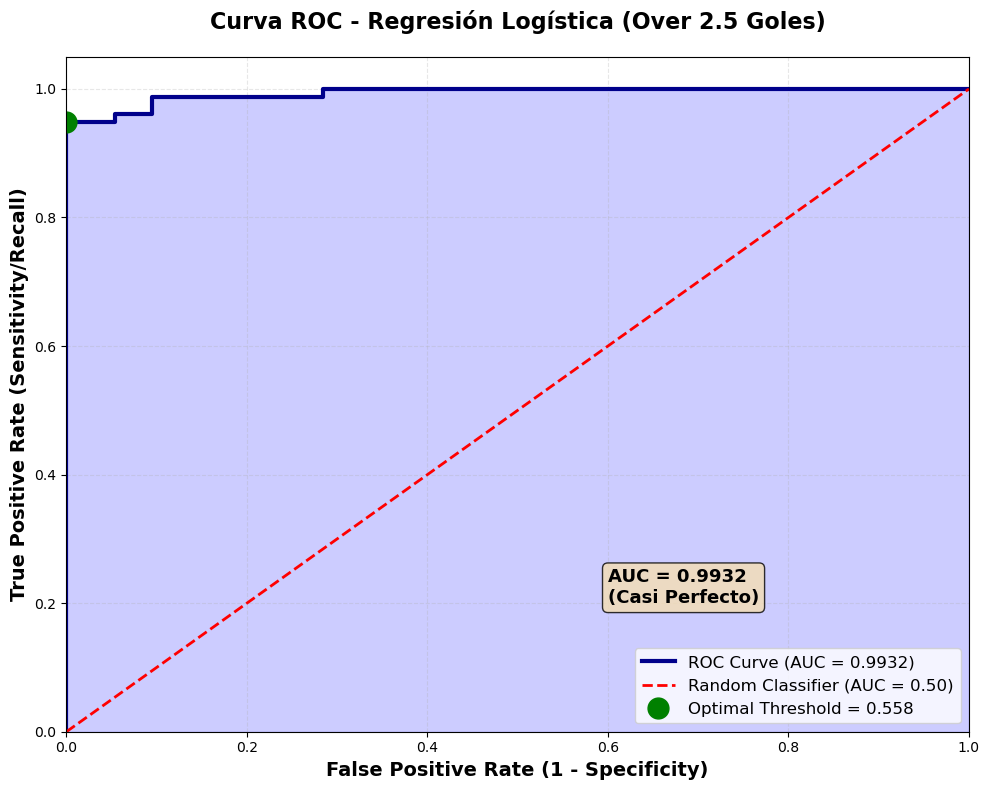

In [42]:
print("="*80)
print("GENERANDO CURVA ROC")
print("="*80)

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_2_5_test, y_2_5_test_proba)
roc_auc = auc(fpr, tpr)

# Crear figura
plt.figure(figsize=(10, 8))

# Curva ROC
plt.plot(fpr, tpr, color='darkblue', lw=3, 
         label=f'ROC Curve (AUC = {roc_auc:.4f})')

# Línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', 
         label='Random Classifier (AUC = 0.50)')

# Punto óptimo
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
plt.plot(fpr[optimal_idx], tpr[optimal_idx], 'go', markersize=15, 
         label=f'Optimal Threshold = {optimal_threshold:.3f}')

# Configuración del gráfico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=14, fontweight='bold')
plt.title('Curva ROC - Regresión Logística (Over 2.5 Goles)', 
          fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3, linestyle='--')

# Área bajo la curva
plt.fill_between(fpr, tpr, alpha=0.2, color='blue', label='AUC Area')

# Leyenda
plt.text(0.6, 0.2, f'AUC = {roc_auc:.4f}\n(Casi Perfecto)', 
         fontsize=13, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         fontweight='bold')

plt.tight_layout()

Se muestra la curva ROC del modelo de regresión logística para la predicción de partidos con más de 2.5 goles. 

El área bajo la curva (AUC) de 0.9932 indica una capacidad de discriminación casi perfecta entre ambas clases. La curva se aproxima a la esquina superior izquierda, alcanzando un ratio de Verdaderos Positivos = 95% y los Falsos Positivos cerca de 0. Esto indica que el modelo está bien calibrado, con separación entre partido Over 2.5 y Under 2.5.

El punto óptimo de la curva ROC se alcanza con un threshold de probabilidad de 0.558, generando coordenadas de FPR≈0.0 y TPR≈0.95 (visible en el eje Y del gráfico, por encima de 0.9). Este threshold de 0.558 significa que el modelo solo predice Over 2.5 cuando la probabilidad calculada es igual o superior al 55.8%, balance entre specifity y recall.

### 4.4. Random Forest

In [43]:
print("\n\n🔮 Realizando predicciones Random Forest...")
print("-"*80)

y_rf_train_pred = modelo_rf.predict(X_2_5_train)
y_rf_test_pred = modelo_rf.predict(X_2_5_test)

y_rf_train_proba = modelo_rf.predict_proba(X_2_5_train)[:, 1]
y_rf_test_proba = modelo_rf.predict_proba(X_2_5_test)[:, 1]

print("✅ Predicciones realizadas")

print("\n\n📈 Evaluando el modelo Random Forest...")
print("="*80)

# Métricas en TRAIN
accuracy_train_rf = accuracy_score(y_2_5_train, y_rf_train_pred)
precision_train_rf = precision_score(y_2_5_train, y_rf_train_pred)
recall_train_rf = recall_score(y_2_5_train, y_rf_train_pred)
f1_train_rf = f1_score(y_2_5_train, y_rf_train_pred)
roc_auc_train_rf = roc_auc_score(y_2_5_train, y_rf_train_proba)

# Métricas en TEST
accuracy_test_rf = accuracy_score(y_2_5_test, y_rf_test_pred)
precision_test_rf = precision_score(y_2_5_test, y_rf_test_pred)
recall_test_rf = recall_score(y_2_5_test, y_rf_test_pred)
f1_test_rf = f1_score(y_2_5_test, y_rf_test_pred)
roc_auc_test_rf = roc_auc_score(y_2_5_test, y_rf_test_proba)

print(f"\n📊 MÉTRICAS EN TRAIN:")
print(f"   Accuracy:  {accuracy_train_rf:.4f} ({accuracy_train_rf*100:.2f}%)")
print(f"   Precision: {precision_train_rf:.4f}")
print(f"   Recall:    {recall_train_rf:.4f}")
print(f"   F1-Score:  {f1_train_rf:.4f}")
print(f"   ROC-AUC:   {roc_auc_train_rf:.4f}")

print(f"\n📊 MÉTRICAS EN TEST:")
print(f"   Accuracy:  {accuracy_test_rf:.4f} ({accuracy_test_rf*100:.2f}%)")
print(f"   Precision: {precision_test_rf:.4f}")
print(f"   Recall:    {recall_test_rf:.4f}")
print(f"   F1-Score:  {f1_test_rf:.4f}")
print(f"   ROC-AUC:   {roc_auc_test_rf:.4f}")



🔮 Realizando predicciones Random Forest...
--------------------------------------------------------------------------------
✅ Predicciones realizadas


📈 Evaluando el modelo Random Forest...

📊 MÉTRICAS EN TRAIN:
   Accuracy:  0.9967 (99.67%)
   Precision: 0.9968
   Recall:    0.9968
   F1-Score:  0.9968
   ROC-AUC:   0.9999

📊 MÉTRICAS EN TEST:
   Accuracy:  0.9408 (94.08%)
   Precision: 0.9600
   Recall:    0.9231
   F1-Score:  0.9412
   ROC-AUC:   0.9915


In [44]:
cm = confusion_matrix(y_2_5_test, y_rf_test_pred)
print(f"\n📊 MATRIZ DE CONFUSIÓN (Test):")
print(f"\n                 Predicho")
print(f"              Under 2.5  Over 2.5")
print(f"Real Under 2.5    {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"Real Over 2.5     {cm[1,0]:4d}      {cm[1,1]:4d}")

tn, fp, fn, tp = cm.ravel()
print(f"\n   True Negatives:  {tn}")
print(f"   False Positives: {fp}")
print(f"   False Negatives: {fn}")
print(f"   True Positives:  {tp}")


📊 MATRIZ DE CONFUSIÓN (Test):

                 Predicho
              Under 2.5  Over 2.5
Real Under 2.5      71         3
Real Over 2.5        6        72

   True Negatives:  71
   False Positives: 3
   False Negatives: 6
   True Positives:  72


Se entrenó un modelo Random Forest con 100 árboles y profundidad máxima de 10, obteniendo un accuracy de 94.08% en el conjunto de test.

Aunque el rendimiento es excelente en general, hay un overfitting moderado: accuracy de 99.67% en train vs 94.08% en test (diferencia de 5.59%). El modelo captura patrones específicos del conjunto de entrenamiento que no generalizan completamente.

Comparando con Regresión Logística:
- Accuracy: 94.08% vs 97.37% (3.29% peor)
- Precision: 96.00% vs 100.00% (4% peor)
- Recall: 92.31% vs 94.87% (2.56% peor)
- ROC-AUC: 99.15% vs 99.32% (similar)

El problema de clasificación Over/Under 2.5 goles tiene una naturaleza lineal, donde las relaciones directas de las features y target son más que suficientes para una buena predicción, por lo tanto la `Regresión logística` es mejor que el `Random Forest`, ya que este introduce overfitting sin mejorar el rendimiento.